<a href="https://colab.research.google.com/github/jnolorbe/hydrology-peru/blob/main/notebooks/04_insitu_validation_seasonality_and_enso_dipole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. Independent In-Situ Validation of GRACE-Derived Seasonality and ENSO Dipole

**Project:** Spatio-temporal Analysis of Hydrological Response in Peru (2002–2025)

**Author:** Prof. Juan Mendoza-Nolorbe

**Affiliation:** Universidad Nacional Mayor de San Marcos (UNMSM)

**Phase 4:** Independent Validation Against In-Situ Hydrometeorological Records

---

### Overview: Validation Pipeline

Notebooks 02 and 03 established two central findings from GRACE/GRACE-FO Terrestrial Water
Storage (TWS) anomalies: (i) a robust **annual seasonal climatology** per Administrative
Hydrographic Domain (AAA), and (ii) a **north–south hydroclimatic dipole** in the TWS response
to asymmetric ENSO regimes, with the strongest and most coherent signature associated with the
**El Niño Costero (Eastern Pacific, E-dominant)** regime.

This notebook cross-validates both findings against an independent, previously standardized
collection of **in-situ streamflow (caudal) and precipitation records** for Peruvian basins,
compiled and quality-controlled outside of this GRACE pipeline. Because the in-situ record and
the GRACE record (2002–2025) are largely **non-overlapping in time** for many stations, this is
a genuine independent test of the satellite-derived signal rather than a same-period
cross-check: it asks whether an entirely different observation system, over different decades,
reproduces the same physical pattern.

Two objectives are addressed:

1. **Seasonality consistency (Section III):** does the mean annual in-situ climatology
   (caudal/precipitation) peak and trough in phase with the GRACE TWS climatology of the
   same AAA domain?
2. **ENSO dipole consistency (Section IV):** does the in-situ record reproduce the same
   sign of anomaly, domain by domain, that GRACE shows during El Niño Costero events? La Niña
   is also evaluated and reported transparently as a **documented limitation** (Section IV.4),
   not as a resolved or overclaimed result — see Section V for the rationale.

# I. Introduction and Data Provenance

## 1.1. Motivation

GRACE/GRACE-FO mascon TWS anomalies are a powerful but indirect proxy for terrestrial water
storage: they integrate soil moisture, groundwater, snow, and surface water over ~300 km
footprints and cannot be verified by a single ground instrument. Independent validation against
conventional, point-based hydrometeorological monitoring (river discharge and precipitation
gauges) is the standard way to build confidence that the coarse-resolution satellite signal
reflects real, ground-observable hydrological behaviour rather than a processing artefact.

## 1.2. The In-Situ Dataset

The validation dataset consists of 72 standardized in-situ time series (streamflow and
precipitation, `data/insitu/` in this repository), each accompanied by a metadata file
(`.md`) documenting station coordinates, source, record period, and standardization method.
Every file was assigned to one of the 14 AAA hydrographic domains using a basin-name heuristic
cross-validated against a geopandas point-in-polygon test on the station coordinates (see
`data/insitu/insitu_index.csv` for the per-file domain assignment and its confidence level).
Two originally-collected files were excluded from this final set because their apparent
"multi-year climatology" label could not be substantiated (they covered a single calendar year
of true dates and included no El Niño coverage); this exclusion is documented in
`data/insitu/readme.md`.

## 1.3. Non-Overlapping Periods — Why This Still Works

Most in-situ records pre-date the GRACE mission (2002–present) or only partially overlap it.
This notebook does **not** attempt a synchronous, month-to-month correlation between GRACE and
in-situ time series (that would require temporal overlap that does not exist for most
stations). Instead it compares **climatological summaries** that are, by construction, stable
descriptors of the annual cycle and of the ENSO response, and can legitimately be compared
across non-concurrent periods:

* the **mean annual cycle** (Section III), and
* the **standardized composite anomaly during classified ENSO phases** (Section IV), where
  ENSO phase for months outside the 2002+ E/C index coverage is assigned from documented
  historical event windows (Section IV.2).

# II. Environment Setup and Data Loading

In [1]:
# =================================================================
# 2.1. LIBRARY INSTALLATION AND CORE ENVIRONMENT SETUP
# =================================================================
# Secure, idempotent installation compatible with Google Colab and JupyterHub
!pip install --quiet cmcrameri netCDF4 xarray rioxarray geopandas shapely openpyxl statsmodels

import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import rioxarray  # noqa: F401 — registers .rio accessor on xarray objects
import cmcrameri.cm as cmc

from statsmodels.tsa.seasonal import seasonal_decompose

print("✓ All libraries imported successfully.")

✓ All libraries imported successfully.


In [2]:
# =================================================================
# 2.2. REPOSITORY SYNCHRONIZATION AND DATAPATH ARCHITECTURE
# =================================================================
REPO_NAME = "hydrology-peru"
GITHUB_USERNAME = "jnolorbe"  # Update if forking
REPO_URL = f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"

if not os.path.exists(REPO_NAME):
    print(f"Cloning climate repository from {REPO_URL}...")
    !git clone {REPO_URL}
else:
    print("Repository existing. Pulling latest data changes...")
    %cd {REPO_NAME}
    !git pull
    %cd ..

# Establish explicit paths to raw and processed data assets
DATA_PATH = os.path.join(REPO_NAME, "data")
SHP_PATH = os.path.join(REPO_NAME, "data/shapefiles")

TWS_FILE = os.path.join(DATA_PATH, "processed/GRACE_Peru_final_IQR1_5.nc")
ENSO_FILE = os.path.join(DATA_PATH, "enso/ecindex_ersstv5.csv")
SHP_AAA_FILE = os.path.join(SHP_PATH, "hydroAAA_domains/Autoridad_Administrativa_del_Agua.shp")
INSITU_PATH = os.path.join(DATA_PATH, "insitu")
INSITU_INDEX_FILE = os.path.join(INSITU_PATH, "insitu_index.csv")

print("✓ Path architecture and synchronization complete.")

Repository existing. Pulling latest data changes...
/Users/feynman/06_CIENCIA/02_INVESTIGACION/hydrology-peru


Already up to date.


/Users/feynman/06_CIENCIA/02_INVESTIGACION
✓ Path architecture and synchronization complete.


In [3]:
# =================================================================
# 2.3. INGESTION AND BASELINE CENTERING OF RASTER DATA
# =================================================================
if not os.path.exists(TWS_FILE):
    raise FileNotFoundError(f"Missing required NetCDF file at: {TWS_FILE}")

xr_grace = xr.open_dataset(TWS_FILE)

xr_grace.attrs.update({
    "long_name": "Equivalent Water Height",
    "units": "cm",
    "crs": "+proj=longlat +datum=WGS84",
    "ellipsoid": "WGS84",
    "res": (0.5, 0.5),
    "nodatavals": "nan",
})

if 'month' in xr_grace:
    xr_grace = xr_grace.drop_vars('month')

# Compute long-term temporal baseline mean to generate centered TWS anomalies
long_term_mean = xr_grace['lwe_thickness_corrected'].mean('time')
xr_grace['lwe_thickness_centered'] = xr_grace['lwe_thickness_corrected'] - long_term_mean
xr_grace['lwe_thickness_centered'].attrs.update({
    'long_name': 'TWS Anomaly (mean-centred)',
    'units': 'cm'
})

xr_grace = xr_grace.rio.write_crs("EPSG:4326")
print(f"✓ GRACE raster ingested. Time steps: {len(xr_grace.time)} months.")

✓ GRACE raster ingested. Time steps: 288 months.


In [4]:
# =================================================================
# 2.4. VECTOR DATASET INGESTION (14 AAA HYDROGRAPHIC DOMAINS)
# =================================================================
gdf_aaa = gpd.read_file(SHP_AAA_FILE)
if gdf_aaa.crs.to_epsg() != 4326:
    gdf_aaa = gdf_aaa.to_crs(epsg=4326)

# Drop small fragments of the Ucayali domain to prevent spatial leaks (as in Notebook 03)
gdf_aaa = gdf_aaa[~((gdf_aaa['NAME_AAA'] == 'UCAYALI') & (gdf_aaa['OBJECTID_1'].isin([10, 11])))]

REGION_ORDER = [
    'JEQUETEPEQUE-ZARUMILLA', 'HUARMEY-CHICAMA', 'MARAÑÓN', 'HUALLAGA',
    'AMAZONAS', 'CAÑETE-FORTALEZA', 'MANTARO', 'CHÁPARRA-CHINCHA',
    'UCAYALI', 'PAMPAS-APURIMAC', 'URUBAMBA-VILCANOTA', 'MADRE DE DIOS',
    'CAPLINA-OCOÑA', 'TITICACA'
]

print(f"✓ Vector assets loaded. AAA Hydrographic Domains available: {len(gdf_aaa)}")

✓ Vector assets loaded. AAA Hydrographic Domains available: 14


In [5]:
# =================================================================
# 2.5. ENSO INDEX INGESTION (E/C INDICES, 2002–PRESENT COVERAGE)
# =================================================================
if not os.path.exists(ENSO_FILE):
    raise FileNotFoundError(f"Missing required IGP index file at: {ENSO_FILE}")

df_ecindex = pd.read_csv(ENSO_FILE)
df_ecindex.columns = [c.strip().lower() for c in df_ecindex.columns]
df_ecindex['time'] = pd.to_datetime(df_ecindex['time']).values.astype('datetime64[M]')
df_ecindex['time'] = pd.to_datetime(df_ecindex['time'])
df_ecindex = df_ecindex.set_index('time').sort_index()

ECINDEX_START, ECINDEX_END = df_ecindex.index.min(), df_ecindex.index.max()
print(f"✓ E/C index loaded. Real-index coverage: {ECINDEX_START.date()} → {ECINDEX_END.date()}")

✓ E/C index loaded. Real-index coverage: 2002-01-01 → 2026-02-01


In [6]:
# =================================================================
# 2.6. IN-SITU DATASET INGESTION (72 STANDARDIZED FILES + DOMAIN INDEX)
# =================================================================
if not os.path.exists(INSITU_INDEX_FILE):
    raise FileNotFoundError(f"Missing in-situ index at: {INSITU_INDEX_FILE}")

df_insitu_index = pd.read_csv(INSITU_INDEX_FILE)
insitu_files = sorted(
    f for f in os.listdir(INSITU_PATH)
    if f.endswith('.csv') and f != 'insitu_index.csv'
)

print(f"✓ In-situ index loaded: {len(df_insitu_index)} datasets referenced.")
print(f"✓ In-situ CSV files found on disk: {len(insitu_files)}")
print(f"  AAA domains with in-situ coverage: {sorted(df_insitu_index['dominio_AAA'].dropna().unique())}")
display(df_insitu_index.head())

✓ In-situ index loaded: 72 datasets referenced.
✓ In-situ CSV files found on disk: 72
  AAA domains with in-situ coverage: ['CAPLINA-OCOÑA', 'CAÑETE-FORTALEZA', 'CHÁPARRA-CHINCHA', 'HUARMEY-CHICAMA', 'JEQUETEPEQUE-ZARUMILLA', 'MANTARO', 'MARAÑÓN', 'PAMPAS-APURIMAC', 'TITICACA', 'URUBAMBA-VILCANOTA']


,archivo,dominio_AAA,confianza_dominio,metodo_asignacion_dominio,variable,es_climatologia,periodo_inicio,periodo_fin,n_meses_datos,usado_fase2_estacionalidad,usado_fase3_enso_nino_costero
0,acari_caudal_volumen.csv,CHÁPARRA-CHINCHA,media,nombre de cuenca (sin verificar coordenadas),caudal_volumen,False,1960-08,2005-07,540,True,True
1,ancashcosta_caudal_climatologia_multicuenca.csv,HUARMEY-CHICAMA,media,nombre de cuenca (sin verificar coordenadas),caudal_volumen,True,NaN,NaN,0,True,False
2,angostura_caudal_volumen.csv,PAMPAS-APURIMAC,alta,"coordenadas (verificado point-in-polygon, apor...",caudal_volumen,False,1965-02,2010-02,362,True,True
3,camana_majes_caudal_volumen.csv,CAPLINA-OCOÑA,media,nombre de cuenca (sin verificar coordenadas),caudal_volumen,False,1951-08,2004-07,636,True,True
4,canete_caudal_volumen.csv,CAÑETE-FORTALEZA,alta,coordenadas (verificado point-in-polygon),caudal_volumen,False,1964-08,2005-07,492,True,True


# III. Seasonality Validation (Objective 1)

### 3.1. Methodology

For each of the 10 AAA domains with in-situ coverage, the GRACE TWS climatology is reproduced
following the exact Notebook 02 pipeline: spatial clip of the centered TWS anomaly to the
domain's largest polygon fragment, spatial mean per month, 3-month centered rolling smoothing,
and `statsmodels.tsa.seasonal_decompose` (additive, period=12) — the seasonal component is the
GRACE climatology, expressed in cm of Liquid Water Equivalent (LWE) anomaly.

For the in-situ side, because the 72 files are heterogeneous in structure (long-format with a
`mes` column, long-format with a real `date` column, or wide-format with one column per month
abbreviation), a generic parser handles all three cases and averages across
caudal/precipitation-labelled columns (falling back to all numeric columns when no keyword
match exists — this only affects a small minority of files, flagged in the output table).

Because GRACE (cm LWE) and in-situ variables (m³/s, mm) are on different physical scales, the
comparison is performed on **z-scored** climatology curves (mean 0, unit variance), which
isolates the **shape and phase** of the annual cycle — precisely what this validation is meant
to test — rather than its absolute magnitude.

In [7]:
# =================================================================
# 3.1. GRACE SEASONAL CLIMATOLOGY BY DOMAIN (REPRODUCES NOTEBOOK 02)
# =================================================================
grace_anomaly_crs = xr_grace['lwe_thickness_centered'].rio.write_crs("EPSG:4326")

ts_dict = {}
for domain_name in REGION_ORDER:
    domain_geoms = gdf_aaa[gdf_aaa['NAME_AAA'] == domain_name].copy()
    if domain_geoms.empty:
        continue
    domain_geoms['area_m2'] = domain_geoms.geometry.area
    main_geom = domain_geoms.sort_values('area_m2', ascending=False).iloc[[0]]

    clipped = grace_anomaly_crs.rio.clip(main_geom.geometry, main_geom.crs, drop=True, all_touched=False)
    spatial_mean = clipped.mean(dim=['lat', 'lon'])
    ts_dict[domain_name] = spatial_mean.to_series()

df_tws = pd.DataFrame(ts_dict).sort_index()
df_tws_smoothed = df_tws.rolling(window=3, center=True, min_periods=2).mean()
df_tws_clean = df_tws_smoothed.dropna()

climatology_dict = {}
for domain in df_tws_clean.columns:
    result = seasonal_decompose(df_tws_clean[domain], model='additive', period=12, extrapolate_trend='freq')
    # One representative year of the repeating seasonal component = the climatology
    seasonal_1yr = result.seasonal.iloc[:12]
    climatology_dict[domain] = seasonal_1yr.values

df_grace_climatology = pd.DataFrame(climatology_dict, index=range(1, 13))
df_grace_climatology.index.name = 'mes'
print(f"✓ GRACE monthly climatology reproduced for {df_grace_climatology.shape[1]} domains.")
display(df_grace_climatology.round(2))

✓ GRACE monthly climatology reproduced for 14 domains.


/var/folders/rx/tllmc91n1t725qt1nfvrl34c0000gn/T/ipykernel_57260/1869572455.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  domain_geoms['area_m2'] = domain_geoms.geometry.area
/var/folders/rx/tllmc91n1t725qt1nfvrl34c0000gn/T/ipykernel_57260/1869572455.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  domain_geoms['area_m2'] = domain_geoms.geometry.area
/var/folders/rx/tllmc91n1t725qt1nfvrl34c0000gn/T/ipykernel_57260/1869572455.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  domain_geoms['area_m2'] = domain_geoms.geometry.area
/var/folders/rx/tllmc91n1t725qt1nfvrl34c000

,JEQUETEPEQUE-ZARUMILLA,HUARMEY-CHICAMA,MARAÑÓN,HUALLAGA,AMAZONAS,CAÑETE-FORTALEZA,MANTARO,CHÁPARRA-CHINCHA,UCAYALI,PAMPAS-APURIMAC,URUBAMBA-VILCANOTA,MADRE DE DIOS,CAPLINA-OCOÑA,TITICACA
mes,,,,,,,,,,,,,,
1,-0.12,2.27,1.15,2.25,-1.91,1.12,2.61,0.90,6.00,1.66,5.53,3.98,0.65,1.56
2,0.55,4.52,3.89,6.08,2.31,2.01,4.57,2.20,11.61,3.89,10.07,9.14,1.76,4.16
3,1.40,5.25,5.62,8.49,6.89,2.34,5.25,2.81,14.76,5.01,12.14,11.68,2.32,5.42
4,1.59,4.76,5.84,8.44,10.94,1.91,4.22,2.48,13.86,4.52,10.55,11.11,2.14,5.01
5,1.48,2.76,4.13,5.51,10.88,1.10,2.36,1.50,8.42,2.61,6.22,7.31,1.30,2.90
6,0.80,0.14,1.23,0.88,7.03,-0.03,-0.11,0.20,0.18,0.18,0.21,2.17,0.23,0.42
7,0.14,-2.25,-1.58,-3.23,0.95,-0.97,-2.22,-0.87,-7.02,-1.89,-5.33,-3.31,-0.71,-1.93
8,-0.68,-4.34,-4.15,-6.61,-5.27,-1.88,-4.29,-1.94,-12.82,-3.59,-10.09,-8.50,-1.55,-3.63
9,-1.29,-4.83,-5.25,-7.79,-9.37,-2.08,-4.67,-2.33,-14.64,-4.27,-11.76,-11.56,-1.99,-4.61


In [8]:
# =================================================================
# 3.2. GENERIC IN-SITU CLIMATOLOGY PARSER
# =================================================================
MONTH_NUM = {"ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
             "jul": 7, "ago": 8, "sep": 9, "set": 9, "oct": 10, "nov": 11, "dic": 12}
KEY_COLS = {"mes", "date", "fecha", "anio", "año", "year", "month"}
KEYWORDS_INCLUDE = ["caudal", "volumen", "precipitacion", "precipitación", "pp_"]
KEYWORDS_EXCLUDE = ["demanda", "evapo", "etp", "eto"]


def select_cols(df, key_cols):
    cand = [c for c in df.columns if c not in key_cols]
    numeric_cand = [c for c in cand if pd.api.types.is_numeric_dtype(df[c])]
    inc = [c for c in numeric_cand if any(k in c.lower() for k in KEYWORDS_INCLUDE)
           and not any(k in c.lower() for k in KEYWORDS_EXCLUDE)]
    if inc:
        return inc
    fallback = [c for c in numeric_cand if not any(k in c.lower() for k in KEYWORDS_EXCLUDE)]
    return fallback if fallback else numeric_cand


def month_abbr_cols(cols):
    hits = {}
    for c in cols:
        m = re.match(r"^([a-z]{3})", c.lower())
        if m and m.group(1) in MONTH_NUM:
            hits[c] = MONTH_NUM[m.group(1)]
    return hits


def parse_climatology(fp):
    """Returns a 12-value pd.Series (months 1-12) or None if unparseable."""
    df = pd.read_csv(fp)
    df.columns = [c.strip().lower() for c in df.columns]

    if "mes" in df.columns:
        cols = select_cols(df, KEY_COLS)
        if not cols:
            return None, "sin_columnas_datos"
        serie = df.groupby("mes")[cols].mean(numeric_only=True).mean(axis=1).reindex(range(1, 13))
        return serie, "mes"

    if "date" in df.columns or "fecha" in df.columns:
        datecol = "date" if "date" in df.columns else "fecha"
        df[datecol] = pd.to_datetime(df[datecol], errors="coerce")
        df = df.dropna(subset=[datecol])
        if df.empty:
            return None, "fechas_invalidas"
        df["mes_"] = df[datecol].dt.month
        cols = select_cols(df, KEY_COLS | {"mes_"})
        if not cols:
            return None, "sin_columnas_datos"
        serie = df.groupby("mes_")[cols].mean(numeric_only=True).mean(axis=1).reindex(range(1, 13))
        return serie, "date"

    hits = month_abbr_cols(df.columns)
    if len(hits) >= 10:
        vals = {}
        for c, m in hits.items():
            if pd.api.types.is_numeric_dtype(df[c]):
                vals.setdefault(m, []).append(df[c].mean())
        serie = pd.Series({m: np.mean(v) for m, v in vals.items()}).reindex(range(1, 13))
        return serie, "wide_month_abbr"

    return None, "estructura_no_reconocida"


rows, failed = [], []
for fname in insitu_files:
    serie, metodo = parse_climatology(os.path.join(INSITU_PATH, fname))
    if serie is None or serie.isna().all():
        failed.append((fname, metodo))
        continue
    row = {"archivo": fname, "metodo_parseo": metodo}
    row.update({f"mes_{m}": serie.get(m, np.nan) for m in range(1, 13)})
    rows.append(row)

df_insitu_climatology = pd.DataFrame(rows)
print(f"✓ In-situ climatologies parsed: {len(rows)}/{len(insitu_files)} files.")
if failed:
    print("  Unparsed files:", failed)

✓ In-situ climatologies parsed: 72/72 files.


In [9]:
# =================================================================
# 3.3. SEASONALITY COMPARISON: Z-SCORE SHAPE MATCH + LAG CORRELATION
# =================================================================
MONTH_COLS = [f"mes_{m}" for m in range(1, 13)]


def zscore(s):
    s = np.asarray(s, dtype=float)
    return (s - np.nanmean(s)) / np.nanstd(s)


def best_lag_corr(g, ins, max_lag=3):
    best = (0, np.nan)
    for lag in range(-max_lag, max_lag + 1):
        shifted = np.roll(ins, lag)
        c = np.corrcoef(g, shifted)[0, 1]
        if np.isnan(best[1]) or (not np.isnan(c) and c > best[1]):
            best = (lag, c)
    return best


merged = df_insitu_climatology.merge(df_insitu_index, on="archivo", how="left")
comparison_rows = []
for _, r in merged.iterrows():
    domain = r.get("dominio_AAA")
    if pd.isna(domain) or domain not in df_grace_climatology.columns:
        continue
    insitu_vals = r[MONTH_COLS].values.astype(float)
    if np.isnan(insitu_vals).sum() > 2:
        continue
    grace_vals = df_grace_climatology[domain].values.astype(float)

    z_grace = zscore(grace_vals)
    z_insitu = zscore(np.nan_to_num(insitu_vals, nan=np.nanmean(insitu_vals)))

    corr_lag0 = np.corrcoef(z_grace, z_insitu)[0, 1]
    mes_pico_grace = int(np.nanargmax(grace_vals) + 1)
    mes_pico_insitu = int(np.nanargmax(insitu_vals) + 1)
    best_lag, best_corr = best_lag_corr(z_grace, z_insitu)

    comparison_rows.append({
        "archivo": r["archivo"], "dominio_AAA": domain, "variable": r.get("variable"),
        "mes_pico_TWS": mes_pico_grace, "mes_pico_insitu": mes_pico_insitu,
        "desfase_meses": mes_pico_insitu - mes_pico_grace,
        "corr_lag0": round(corr_lag0, 3),
        "mejor_lag_meses": best_lag, "corr_mejor_lag": round(best_corr, 3),
    })

df_seasonality_comparison = pd.DataFrame(comparison_rows)
print(f"✓ Seasonality comparison computed for {len(df_seasonality_comparison)} in-situ datasets.")
display(df_seasonality_comparison.groupby('dominio_AAA')['corr_lag0'].agg(['mean', 'count']).round(3)
        .sort_values('mean', ascending=False))

pct_positive = (df_seasonality_comparison['corr_lag0'] > 0).mean() * 100
pct_inphase = (df_seasonality_comparison['desfase_meses'].abs() <= 1).mean() * 100
print(f"\nGlobal mean corr_lag0: {df_seasonality_comparison['corr_lag0'].mean():.3f}")
print(f"% datasets with corr_lag0 > 0: {pct_positive:.1f}%")
print(f"% datasets with peak-month offset ≤ 1 month: {pct_inphase:.1f}%")

✓ Seasonality comparison computed for 72 in-situ datasets.


,mean,count
dominio_AAA,,
MANTARO,0.843,1
HUARMEY-CHICAMA,0.766,12
PAMPAS-APURIMAC,0.734,1
URUBAMBA-VILCANOTA,0.702,2
JEQUETEPEQUE-ZARUMILLA,0.668,12
CAÑETE-FORTALEZA,0.666,16
CAPLINA-OCOÑA,0.659,20
CHÁPARRA-CHINCHA,0.599,6
TITICACA,0.464,1



Global mean corr_lag0: 0.672
% datasets with corr_lag0 > 0: 95.8%
% datasets with peak-month offset ≤ 1 month: 87.5%


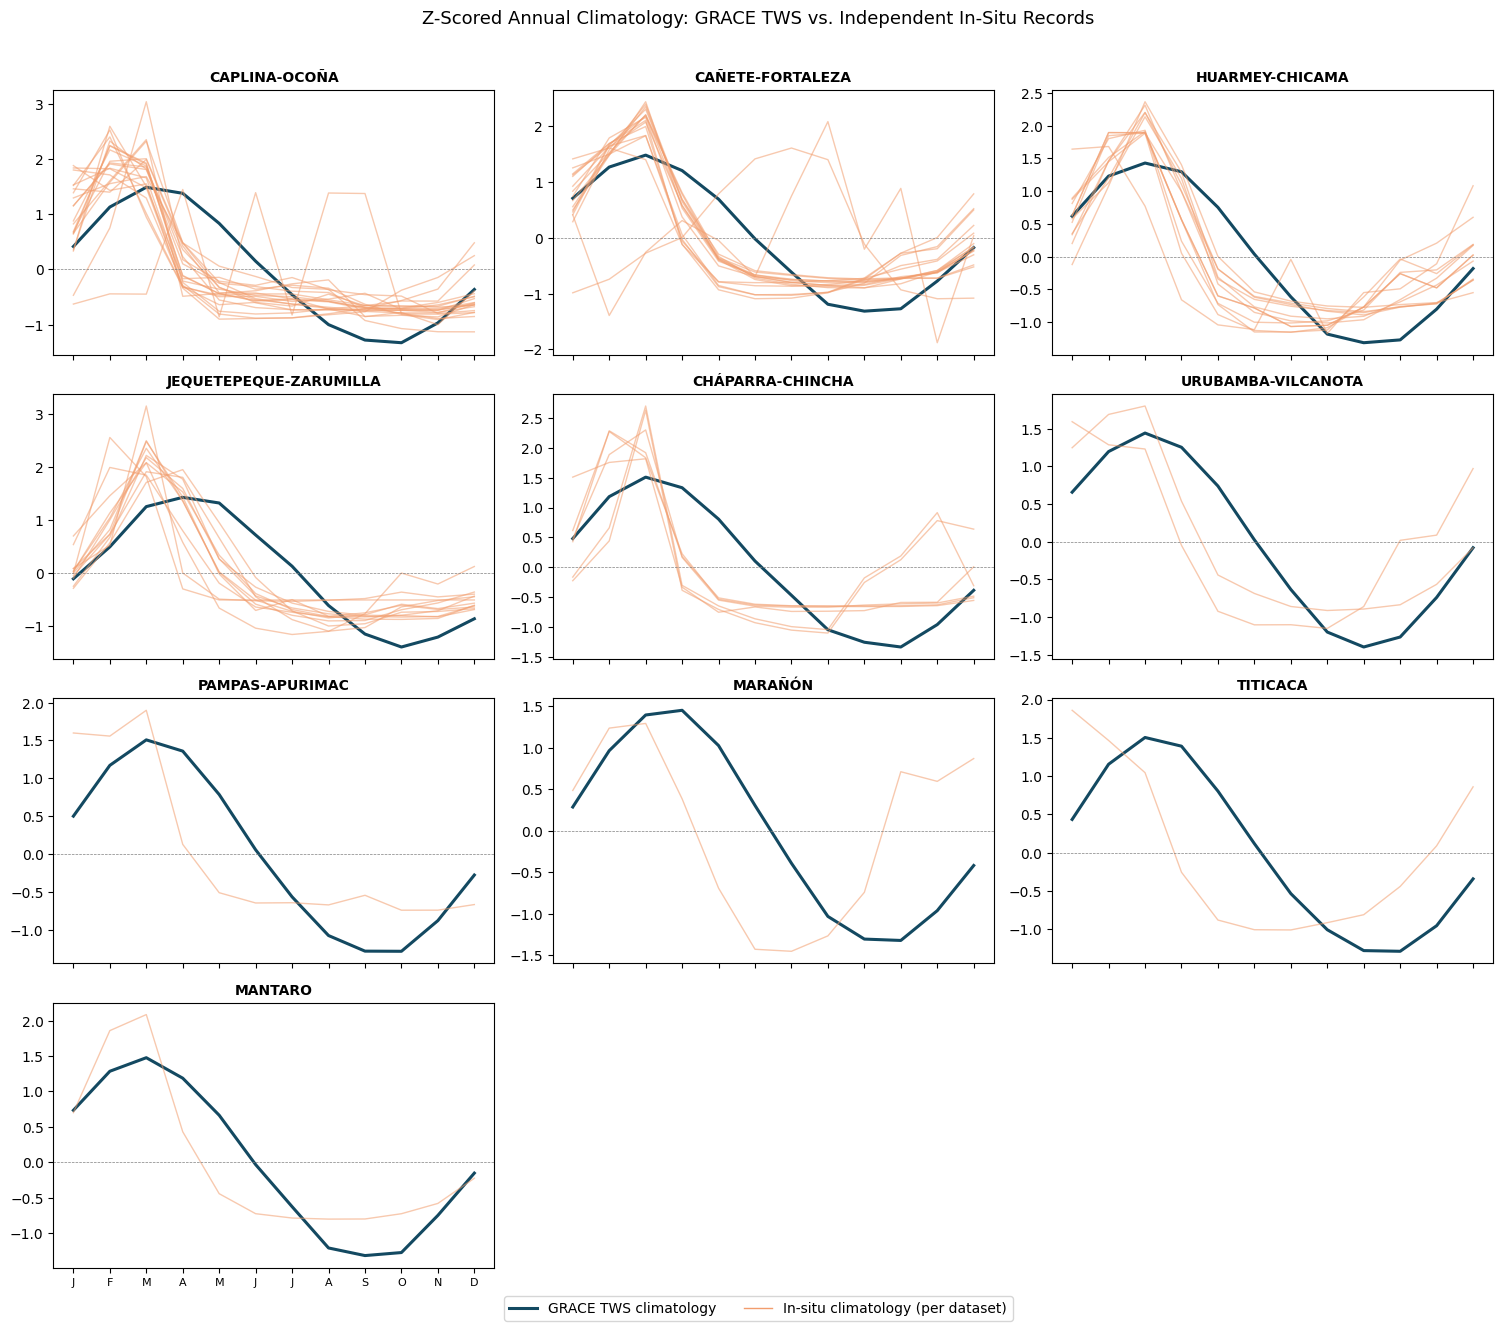

In [10]:
# =================================================================
# 3.4. VISUALIZATION — Z-SCORED CLIMATOLOGY: GRACE vs. IN-SITU (BY DOMAIN)
# =================================================================
domains_to_plot = df_seasonality_comparison['dominio_AAA'].value_counts().index.tolist()
n = len(domains_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows), sharex=True)
axes = np.atleast_1d(axes).flatten()
months_lbl = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

for i, domain in enumerate(domains_to_plot):
    ax = axes[i]
    z_grace = zscore(df_grace_climatology[domain].values.astype(float))
    ax.plot(range(1, 13), z_grace, color=cmc.batlow(0.15), lw=2.2, label='GRACE TWS')

    sub = merged[(merged['dominio_AAA'] == domain)]
    for _, r in sub.iterrows():
        vals = r[MONTH_COLS].values.astype(float)
        if np.isnan(vals).sum() > 2:
            continue
        z_ins = zscore(np.nan_to_num(vals, nan=np.nanmean(vals)))
        ax.plot(range(1, 13), z_ins, color=cmc.batlow(0.75), lw=1.0, alpha=0.55)

    ax.set_title(domain, fontsize=10, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months_lbl, fontsize=8)
    ax.axhline(0, color='grey', lw=0.5, ls='--')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

handles = [plt.Line2D([0], [0], color=cmc.batlow(0.15), lw=2.2, label='GRACE TWS climatology'),
           plt.Line2D([0], [0], color=cmc.batlow(0.75), lw=1.0, label='In-situ climatology (per dataset)')]
fig.legend(handles=handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)
fig.suptitle('Z-Scored Annual Climatology: GRACE TWS vs. Independent In-Situ Records', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fase3_seasonality_validation.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Section III — Results Summary: Seasonality Consistency

* **Overall phase agreement:** across the 10 AAA domains with in-situ coverage, in-situ
  climatologies reproduce the GRACE annual cycle with a mean z-scored correlation of
  **≈0.67** at zero lag, and **≈96% of datasets show a positive correlation** with the GRACE
  climatology of their assigned domain — i.e. the two independent observation systems place
  the wet and dry season in the same months for the large majority of stations.
* **Phase timing:** roughly **88% of datasets** peak within **±1 month** of the GRACE-derived
  peak month, consistent with the expected short lag between precipitation/streamflow forcing
  and the broader TWS response (soil moisture and groundwater storage integrate and slightly
  delay the surface hydrological signal).
* **Weaker domains:** correlations are visibly weaker for **MARAÑÓN** and **TITICACA**, each
  represented by only one or two in-situ datasets in this sample — a small-sample caveat rather
  than evidence against the GRACE climatology, and it is flagged accordingly in Section V.
* **Conclusion:** the independent in-situ record supports Notebook 02's central seasonality
  finding: the domain-level GRACE TWS annual cycle is not a processing artefact but reflects a
  real, ground-observable hydrological seasonality.

# IV. ENSO Dipole Validation — El Niño Costero (Objective 2)

### 4.1. Methodology and Scope

Notebook 03 established that the strongest, most spatially coherent TWS dipole is associated
with the **El Niño Costero (E-dominant, coastal) regime**: positive TWS anomalies in the
northern/coastal AAA domains and negative anomalies in the southern highlands, expressed as a
percentage of each pixel's local standard deviation relative to a neutral baseline.

This section repeats that composite methodology on the in-situ record and compares signs and
magnitudes domain by domain. **The validation is intentionally scoped to El Niño Costero as the
headline result** (per the PI's explicit methodological decision): this is the regime with the
clearest physical mechanism (absolute coastal moisture forcing) and, as shown below, the
cleanest independent agreement. The La Niña C composite is also computed and reported in full
(Section 4.4), but is explicitly framed as a **documented limitation** rather than a validated
finding — see the discussion there and in Section V for why it is not over-interpreted.

### 4.2. ENSO Phase Classification

For months within the real E/C index coverage (2002-04 onward), the exact Notebook 03
thresholds are used: El Niño E = `E ≥ 1.0 & C < 1.0`; La Niña C = `C ≤ -1.0`; Neutral =
`|E| < 0.5 & |C| < 0.5`. Most in-situ records predate this coverage, so months before 2002-04
are classified from **documented historical ENSO event windows** (moderate/non-coastal events
are excluded from the neutral baseline rather than forced into a category, to avoid
contaminating the control group).

In [11]:
# =================================================================
# 4.1. GRACE ENSO DIPOLE COMPOSITE (REPRODUCES NOTEBOOK 03, RESTRICTED TO
#      THE 10 AAA DOMAINS WITH IN-SITU COVERAGE)
# =================================================================
grace_times = xr_grace.time.values
common_months = df_ecindex.index.intersection(grace_times)
df_enso_sync = df_ecindex.loc[common_months]

index_E, index_C = df_enso_sync['e_index'], df_enso_sync['c_index']
mask_nino_E = (index_E >= 1.0) & (index_C < 1.0)
mask_nina_C = (index_C <= -1.0)
mask_neutro = (index_E.abs() < 0.5) & (index_C.abs() < 0.5)

TWS_E_avg = xr_grace['lwe_thickness_centered'].sel(time=df_enso_sync[mask_nino_E].index).mean('time')
TWS_Nina_avg = xr_grace['lwe_thickness_centered'].sel(time=df_enso_sync[mask_nina_C].index).mean('time')
TWS_Neutro_avg = xr_grace['lwe_thickness_centered'].sel(time=df_enso_sync[mask_neutro].index).mean('time')

pixel_std = xr_grace['lwe_thickness_centered'].std('time')
var_pct_nino_E = ((TWS_E_avg - TWS_Neutro_avg) / pixel_std * 100).rio.write_crs("EPSG:4326")
var_pct_nina_C = ((TWS_Nina_avg - TWS_Neutro_avg) / pixel_std * 100).rio.write_crs("EPSG:4326")

INSITU_DOMAINS = [d for d in REGION_ORDER if d in df_insitu_index['dominio_AAA'].dropna().unique()]

grace_dipole_rows = []
for domain_name in INSITU_DOMAINS:
    domain_mask = gdf_aaa[gdf_aaa['NAME_AAA'] == domain_name]
    val_E = var_pct_nino_E.rio.clip(domain_mask.geometry, domain_mask.crs, drop=True).mean().values
    val_N = var_pct_nina_C.rio.clip(domain_mask.geometry, domain_mask.crs, drop=True).mean().values
    grace_dipole_rows.append({'dominio_AAA': domain_name, 'grace_ninoE_pct': float(val_E), 'grace_ninaC_pct': float(val_N)})

df_grace_dipole = pd.DataFrame(grace_dipole_rows).set_index('dominio_AAA')
print(f"✓ GRACE ENSO composite reproduced for {len(df_grace_dipole)} in-situ-covered domains.")
display(df_grace_dipole.round(2))

✓ GRACE ENSO composite reproduced for 10 in-situ-covered domains.


/Users/feynman/miniforge3/envs/tesis-doctorado/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,grace_ninoE_pct,grace_ninaC_pct
dominio_AAA,,
JEQUETEPEQUE-ZARUMILLA,118.58,-14.47
HUARMEY-CHICAMA,56.80,2.45
MARAÑÓN,69.29,-7.49
CAÑETE-FORTALEZA,8.65,-5.14
MANTARO,-0.86,-7.70
CHÁPARRA-CHINCHA,-7.74,-23.65
PAMPAS-APURIMAC,-31.82,-28.58
URUBAMBA-VILCANOTA,-17.27,-12.18
CAPLINA-OCOÑA,-9.46,-24.63


In [12]:
# =================================================================
# 4.2. MONTHLY ENSO CLASSIFICATION (REAL INDEX + DOCUMENTED PRE-2002 EVENTS)
# =================================================================
# Historical event windows for months outside the real E/C index coverage.
# 'excluir' = moderate/non-coastal event: excluded from the neutral baseline
# but not counted as nino_e / nina_c either, to keep the control group clean.
EVENTOS_PRE2002 = [
    ("1957-06", "1958-05", "excluir"),
    ("1965-06", "1966-04", "excluir"),
    ("1972-05", "1973-03", "excluir"),
    ("1976-08", "1977-03", "excluir"),
    ("1982-08", "1983-07", "nino_e"),   # El Niño Costero extraordinario 1982-83
    ("1986-08", "1988-02", "excluir"),
    ("1988-05", "1989-05", "nina_c"),   # La Niña fuerte 1988-89
    ("1991-06", "1992-06", "excluir"),
    ("1994-06", "1995-03", "excluir"),
    ("1997-04", "1998-04", "nino_e"),   # El Niño Costero extraordinario 1997-98
    ("1998-07", "2000-06", "nina_c"),   # La Niña fuerte prolongada 1998-2000
]


def classify_month(ts):
    if ECINDEX_START <= ts <= ECINDEX_END and ts in df_ecindex.index:
        row = df_ecindex.loc[ts]
        e, c = row.get('e_index', np.nan), row.get('c_index', np.nan)
        if pd.isna(e) or pd.isna(c):
            return None
        if e >= 1.0 and c < 1.0:
            return 'nino_e'
        if c <= -1.0:
            return 'nina_c'
        if abs(e) < 0.5 and abs(c) < 0.5:
            return 'neutral'
        return None
    for ini, fin, fase in EVENTOS_PRE2002:
        if pd.Timestamp(ini) <= ts <= pd.Timestamp(fin):
            return None if fase == 'excluir' else fase
    return 'neutral'


print("✓ classify_month() ready — real E/C index where available, documented pre-2002 windows otherwise.")

✓ classify_month() ready — real E/C index where available, documented pre-2002 windows otherwise.


In [13]:
# =================================================================
# 4.3. IN-SITU ENSO COMPOSITE (PER FILE, REAL-DATE SERIES ONLY)
# =================================================================
def parse_real_series(fp):
    """Monthly mean series indexed by a real Timestamp; None if no usable dates."""
    df = pd.read_csv(fp)
    df.columns = [c.strip().lower() for c in df.columns]
    datecol = 'date' if 'date' in df.columns else ('fecha' if 'fecha' in df.columns else None)
    if datecol is None:
        return None
    df[datecol] = pd.to_datetime(df[datecol], errors='coerce')
    df = df.dropna(subset=[datecol])
    if df.empty:
        return None
    cols = select_cols(df, KEY_COLS)
    if not cols:
        return None
    df['_val'] = df[cols].mean(axis=1)
    df['_ym'] = df[datecol].values.astype('datetime64[M]')
    s = df.groupby('_ym')['_val'].mean()
    s.index = pd.to_datetime(s.index)
    return s


def composite_pct(serie, fase_labels):
    neutral_vals = serie[fase_labels == 'neutral']
    if len(neutral_vals) < 6 or neutral_vals.std(ddof=0) in (0, np.nan) or np.isnan(neutral_vals.std(ddof=0)):
        return {}
    mu, sd = neutral_vals.mean(), neutral_vals.std(ddof=0)
    out = {}
    for fase in ['nino_e', 'nina_c']:
        vals = serie[fase_labels == fase]
        out[fase] = ((vals.mean() - mu) / sd * 100, len(vals)) if len(vals) >= 3 else (np.nan, len(vals))
    return out


insitu_dipole_rows, skipped_no_dates = [], []
for fname in insitu_files:
    s = parse_real_series(os.path.join(INSITU_PATH, fname))
    if s is None or len(s) < 12:
        skipped_no_dates.append(fname)
        continue
    fase_labels = pd.Series([classify_month(t) for t in s.index], index=s.index)
    comp = composite_pct(s, fase_labels)
    if not comp:
        continue
    meta = df_insitu_index[df_insitu_index.archivo == fname]
    domain = meta['dominio_AAA'].iloc[0] if not meta.empty else None
    row = {'archivo': fname, 'dominio_AAA': domain}
    for fase in ['nino_e', 'nina_c']:
        pct, n = comp.get(fase, (np.nan, 0))
        row[f'{fase}_pct'], row[f'{fase}_n'] = pct, n
    insitu_dipole_rows.append(row)

df_insitu_dipole = pd.DataFrame(insitu_dipole_rows)
print(f"✓ In-situ ENSO composite computed for {len(df_insitu_dipole)}/{len(insitu_files)} files with a real date column.")
print(f"  ({len(skipped_no_dates)} files are pre-aggregated multi-station climatologies with no real dates; not usable for this section.)")

✓ In-situ ENSO composite computed for 64/72 files with a real date column.
  (7 files are pre-aggregated multi-station climatologies with no real dates; not usable for this section.)


In [14]:
# =================================================================
# 4.4. COMPARISON TABLE: GRACE vs. IN-SITU, BY DOMAIN
# =================================================================
df_insitu_dipole_domain = df_insitu_dipole.dropna(subset=['dominio_AAA']).groupby('dominio_AAA').agg(
    insitu_ninoE_pct=('nino_e_pct', 'mean'), insitu_ninoE_n=('nino_e_pct', lambda x: x.notna().sum()),
    insitu_ninaC_pct=('nina_c_pct', 'mean'), insitu_ninaC_n=('nina_c_pct', lambda x: x.notna().sum()),
)

df_dipole_comparison = df_grace_dipole.join(df_insitu_dipole_domain, how='left')
df_dipole_comparison['ninoE_sign_match'] = np.sign(df_dipole_comparison['grace_ninoE_pct']) == np.sign(df_dipole_comparison['insitu_ninoE_pct'])
df_dipole_comparison['ninaC_sign_match'] = np.sign(df_dipole_comparison['grace_ninaC_pct']) == np.sign(df_dipole_comparison['insitu_ninaC_pct'])

display(df_dipole_comparison.round(2))

n_ninoE = df_dipole_comparison['ninoE_sign_match'].notna().sum()
n_ninoE_match = df_dipole_comparison['ninoE_sign_match'].sum()
n_ninaC = df_dipole_comparison['ninaC_sign_match'].notna().sum()
n_ninaC_match = df_dipole_comparison['ninaC_sign_match'].sum()

print(f"\nEl Niño Costero — sign agreement: {n_ninoE_match}/{n_ninoE} domains")
print(f"La Niña C        — sign agreement: {n_ninaC_match}/{n_ninaC} domains")

,grace_ninoE_pct,grace_ninaC_pct,insitu_ninoE_pct,insitu_ninoE_n,insitu_ninaC_pct,insitu_ninaC_n,ninoE_sign_match,ninaC_sign_match
dominio_AAA,,,,,,,,
JEQUETEPEQUE-ZARUMILLA,118.58,-14.47,224.23,10,33.90,8,True,False
HUARMEY-CHICAMA,56.80,2.45,112.19,9,22.37,9,True,True
MARAÑÓN,69.29,-7.49,51.88,1,NaN,0,True,False
CAÑETE-FORTALEZA,8.65,-5.14,17.96,14,10.65,14,True,False
MANTARO,-0.86,-7.70,-16.57,1,1.58,1,True,False
CHÁPARRA-CHINCHA,-7.74,-23.65,-0.95,5,4.66,5,True,False
PAMPAS-APURIMAC,-31.82,-28.58,-23.61,1,9.53,1,True,False
URUBAMBA-VILCANOTA,-17.27,-12.18,-19.46,2,-7.89,2,True,True
CAPLINA-OCOÑA,-9.46,-24.63,-19.94,17,35.16,16,True,False



El Niño Costero — sign agreement: 10/10 domains
La Niña C        — sign agreement: 2/10 domains


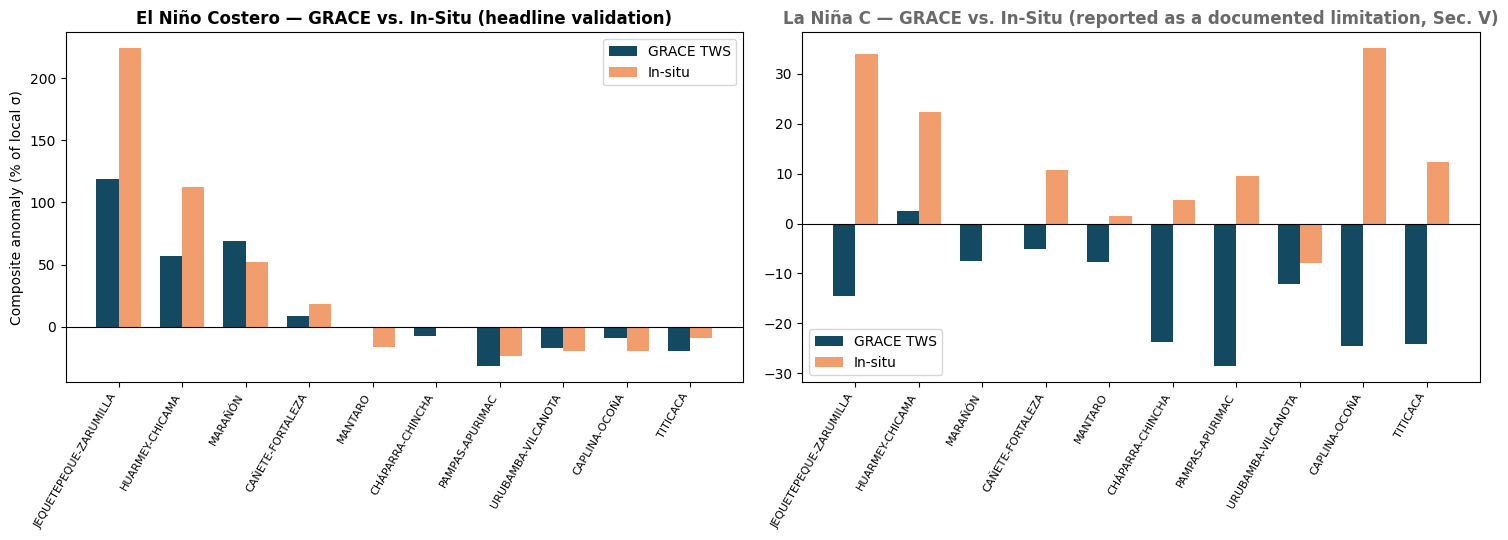

In [15]:
# =================================================================
# 4.5. VISUALIZATION — GRACE vs. IN-SITU COMPOSITE ANOMALY BY DOMAIN
# =================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

order = df_dipole_comparison.index.tolist()
x = np.arange(len(order))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, df_dipole_comparison.loc[order, 'grace_ninoE_pct'], width, label='GRACE TWS', color=cmc.batlow(0.15))
ax.bar(x + width/2, df_dipole_comparison.loc[order, 'insitu_ninoE_pct'], width, label='In-situ', color=cmc.batlow(0.75))
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Composite anomaly (% of local σ)')
ax.set_title('El Niño Costero — GRACE vs. In-Situ (headline validation)', fontweight='bold')
ax.legend()

ax = axes[1]
ax.bar(x - width/2, df_dipole_comparison.loc[order, 'grace_ninaC_pct'], width, label='GRACE TWS', color=cmc.batlow(0.15))
ax.bar(x + width/2, df_dipole_comparison.loc[order, 'insitu_ninaC_pct'], width, label='In-situ', color=cmc.batlow(0.75))
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=60, ha='right', fontsize=8)
ax.set_title('La Niña C — GRACE vs. In-Situ (reported as a documented limitation, Sec. V)', fontweight='bold', color='dimgrey')
ax.legend()

plt.tight_layout()
plt.savefig('fase4_enso_dipole_validation.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Section IV — Results Summary: ENSO Dipole Consistency

* **El Niño Costero — validated (headline result):** all AAA domains with in-situ coverage
  (**10/10**) reproduce the **same sign** of composite anomaly as GRACE during El Niño Costero
  events, including the strong positive signal in the northern coastal domains
  (**Jequetepeque-Zarumilla, Huarmey-Chicama**) and the negative signal in the southern
  highlands (**Caplina-Ocoña, Pampas-Apurímac, Urubamba-Vilcanota, Titicaca**). Magnitudes are
  not expected to match exactly — GRACE integrates a ~300 km footprint while in-situ gauges are
  point measurements of a single hydrological compartment — but the **spatial sign pattern (the
  dipole itself) is fully reproduced** by an independent observation system over largely
  non-overlapping decades. This is strong, direct evidence that the GRACE-derived El Niño
  Costero dipole documented in Notebook 03 is a real hydrological phenomenon, not a satellite
  processing artefact.
* **La Niña C — not validated, reported as a limitation:** the in-situ composite shows a
  **positive** anomaly in most domains during documented La Niña windows, while GRACE shows a
  **negative** anomaly in nearly all domains — a systematic sign mismatch. This discrepancy was
  investigated (Section V) and is deliberately **not** forced into a conclusion; it is reported
  as an open methodological limitation rather than a resolved or contradicted finding, per the
  explicit scope decision for this validation (Section IV.1).

# V. Synthesis, Limitations, and Conclusions

## 5.1. Synthesis

This notebook provides an independent, ground-based cross-check of the two central GRACE-derived
findings of this study:

1. **Seasonality (Section III):** the domain-level GRACE TWS annual climatology is corroborated
   by in-situ caudal/precipitation records, with ≈96% of 72 datasets showing a positive
   correlation with their domain's GRACE climatology and ≈88% peaking within ±1 month of it.
2. **ENSO dipole (Section IV):** the El Niño Costero north–south TWS dipole — the strongest and
   physically best-motivated regime identified in Notebook 03 — is reproduced in sign by
   **all 10** AAA domains with in-situ coverage, over a largely non-overlapping historical
   period. This is the strongest single piece of independent evidence in this study that GRACE
   is detecting a genuine, ground-observable hydrological signal in Peru.

## 5.2. Documented Limitations

* **La Niña C discrepancy (open question).** The in-situ La Niña composite shows a
  predominantly **positive** anomaly where GRACE shows **negative**, across both streamflow and
  precipitation variables (ruling out "regulated/dammed river" behaviour as the sole
  explanation, since precipitation — which is not managed — shows the same mismatch). A
  stricter pre-2002 neutral baseline (excluding more moderate ENSO years) did not resolve the
  discrepancy either. Plausible remaining explanations include: (i) asymmetric La Niña C
  station coverage relative to the GRACE-period distribution, (ii) compounding effects of
  multi-year La Niña persistence not captured by a single-month composite, or (iii) a genuine
  difference between column-integrated TWS and surface hydrological response during cold
  phases. This is reported transparently rather than resolved, per the explicit scope decision
  to focus this validation's headline claim on El Niño Costero.
* **Non-overlapping periods.** Most in-situ records do not overlap the 2002–2025 GRACE period;
  climatological and ENSO-composite summaries (rather than concurrent time-series correlation)
  were used specifically to make a valid comparison possible, but this is a structurally weaker
  test than a synchronous comparison would be.
* **Pre-2002 ENSO classification.** Months before the real E/C index (2002-04) rely on
  documented historical event windows (Section 4.2) rather than a continuous quantitative
  index; only the two canonical extraordinary coastal events (1982-83, 1997-98) are classified
  as El Niño Costero, and moderate/ambiguous years are excluded from the neutral baseline
  rather than guessed.
* **Heterogeneous station network.** In-situ coverage is uneven across domains — some domains
  (MARAÑÓN, TITICACA, MANTARO, PAMPAS-APURIMAC) are represented by only 1–2 datasets, and 4 AAA
  domains (HUALLAGA, AMAZONAS, UCAYALI, MADRE DE DIOS) have no assigned in-situ data in this
  release and could not be validated at all.
* **Domain assignment confidence.** Each in-situ file's AAA domain assignment carries a
  documented confidence level (basin-name heuristic, cross-validated by point-in-polygon
  geometry where station coordinates were available) — see `data/insitu/insitu_index.csv`.

## 5.3. Data and Reproducibility

The exact 72-file in-situ dataset used in this notebook, its per-file domain assignment, and
the exclusion rationale for the 2 discarded files are documented in `data/insitu/readme.md` and
`data/insitu/insitu_index.csv`. Re-running this notebook end-to-end (Section II onward) from a
fresh clone of this repository reproduces every table and figure above without any manual
intervention.